# Spotify Product Analytics Project

## Notebook 3 — Product & Behavioral Analytics

### Objective

This notebook focuses on:
- product KPI analysis
- engagement analytics
- behavioral analysis
- feature adoption
- funnel analytics
- executive-level product insights

This notebook simulates how Product Analysts analyze:
- user engagement
- platform usage
- behavioral patterns
- product performance
- content interaction

DATA LOADING

In [1]:
from re import Pattern

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option('display.max_columns', None)

events_df = pd.read_csv(
    "../analytics_data/events.csv"
)

sessions_df = pd.read_csv(
    "../analytics_data/sessions.csv"
)

events_df['ts'] = pd.to_datetime(events_df['ts'])

events_df.head()

,ts,platform,ms_played,conn_country,track_name,artist_name,album_name,track_uri,reason_start,reason_end,shuffle,skipped,offline,incognito_mode,minutes_played,date,hour,day_name,month,week,is_weekend,skip_flag,night_listener,long_play,completion_rate,fully_played,engagement_level,time_diff,new_session,session_id,engagement_score
0,2020-06-21 13:35:24,Windows 10 (10.0.19041; x64; AppX),205906,IN,Let Me Love You,DJ Snake,Encore,spotify:track:5Qjv35Ja2TDt9CXRRo51hh,playbtn,trackdone,False,False,False,False,3.431767,2020-06-21,13,Sunday,6,25,True,0,0,0,0.195913,0,high_engagement,NaN,0,0,1.715883
1,2020-06-21 13:39:37,Windows 10 (10.0.19041; x64; AppX),252534,IN,"Love Me Like You Do - From ""Fifty Shades Of Grey""",Ellie Goulding,Delirium,spotify:track:3zHq9ouUJQFQRf3cm1rRLu,trackdone,trackdone,True,False,False,False,4.208900,2020-06-21,13,Sunday,6,25,True,0,0,0,0.240277,0,high_engagement,4.216667,0,0,2.104450
2,2020-06-21 13:42:51,Windows 10 (10.0.19041; x64; AppX),193266,IN,Mueve La Cintura,Pitbull,Libertad 548,spotify:track:6iLyEBNStoAemStXqGY7qP,trackdone,trackdone,True,False,False,False,3.221100,2020-06-21,13,Sunday,6,25,True,0,0,0,0.183886,0,high_engagement,3.233333,0,0,1.610550
3,2020-06-21 13:45:23,Windows 10 (10.0.19041; x64; AppX),151133,IN,Lean On (with Emiway Bantai),Celina Sharma,Lean On (with Emiway Bantai),spotify:track:61eDLrQvquaTtZRnGFz9Kh,trackdone,endplay,True,False,False,False,2.518883,2020-06-21,13,Sunday,6,25,True,0,0,0,0.143798,0,normal_engagement,2.533333,0,0,1.259442
4,2020-06-21 13:48:30,Windows 10 (10.0.19041; x64; AppX),176000,IN,Sniper,Sukh-E Muzical Doctorz,Sniper,spotify:track:4H1sP4qqOYy4WXtfb0O3mz,playbtn,trackdone,True,False,False,False,2.933333,2020-06-21,13,Sunday,6,25,True,0,0,0,0.167458,0,normal_engagement,3.116667,0,0,1.466667


KPI FRAMEWORK

In [ ]:
#CREATE DATE COLUMN
events_df['date'] = events_df['ts'].dt.date

In [2]:
#DAILY ACTIVITY
dau = (
    events_df
    .groupby('date')
    .size()
    .reset_index(name='daily_events')
)

dau.head()

,date,daily_events
0,2020-06-21,6
1,2020-06-22,30
2,2020-06-23,15
3,2020-06-24,26
4,2020-06-25,12


In [3]:
#WEEKLY ACTIVITY
events_df['week'] = (
    events_df['ts']
    .dt.isocalendar()
    .week
)

wau = (
    events_df
    .groupby('week')
    .size()
    .reset_index(name='weekly_events')
)

In [4]:
#MONTHLY ACTIVITY
events_df['month'] = (
    events_df['ts']
    .dt.month
)

mau = (
    events_df
    .groupby('month')
    .size()
    .reset_index(name='monthly_events')
)

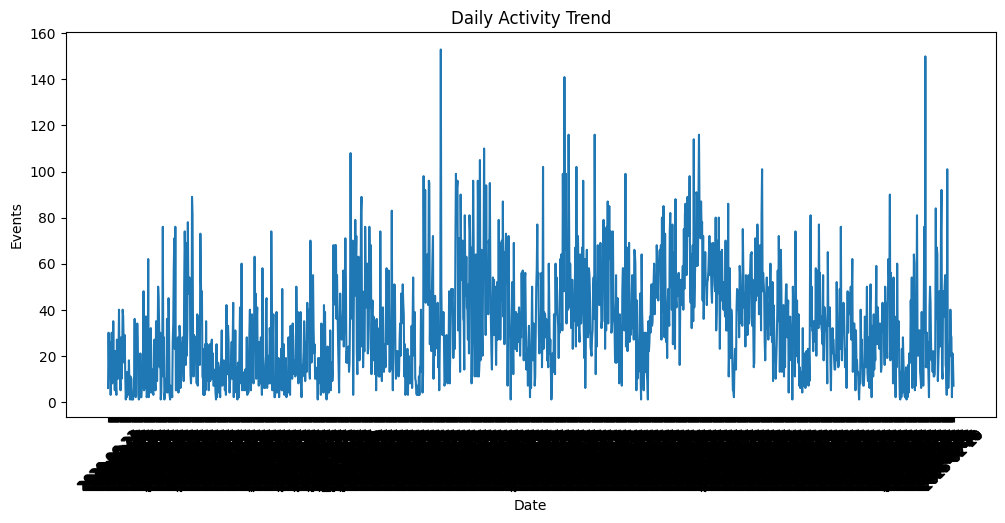

In [5]:
#ACTIVITY TRENDS
plt.figure(figsize=(12,5))

plt.plot(
    dau['date'],
    dau['daily_events']
)

plt.title("Daily Activity Trend")

plt.xlabel("Date")

plt.ylabel("Events")

plt.xticks(rotation=45)

plt.show()

STICKNESS ANALYSIS

In [6]:
#SIMULATED STICKNESS
average_dau = dau['daily_events'].mean()

average_mau = mau['monthly_events'].mean()

stickiness = (
    average_dau / average_mau
)

print("Stickiness Ratio:", round(stickiness, 3))

Stickiness Ratio: 0.007


ENGAGEMENT ANALYSIS

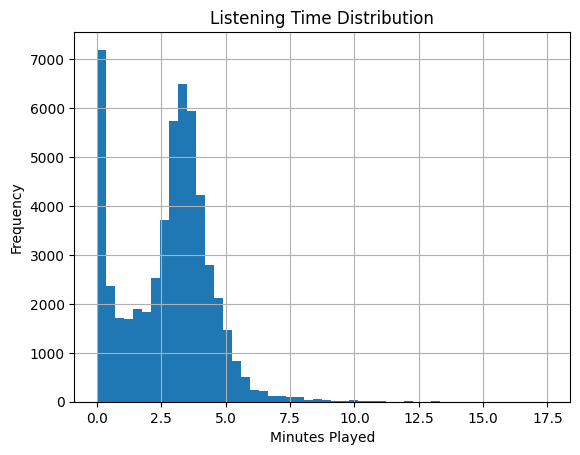

In [7]:
events_df['minutes_played'].hist(
    bins=50
)

plt.title("Listening Time Distribution")

plt.xlabel("Minutes Played")

plt.ylabel("Frequency")

plt.show()

In [ ]:
#AVERAGE LISTENING
events_df['minutes_played'].mean()
#AVERAGE SKIP RATE
events_df['skip_flag'].mean()


SESSION ANALYTICS


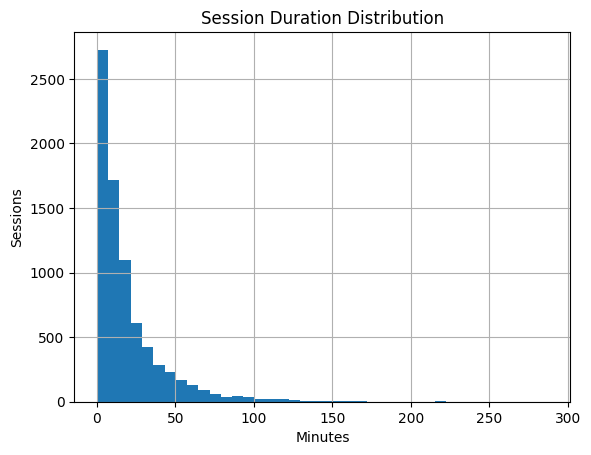

In [8]:
#SESSION DURATION DISTRIBUTION
sessions_df['session_duration'].hist(
    bins=40
)

plt.title("Session Duration Distribution")

plt.xlabel("Minutes")

plt.ylabel("Sessions")

plt.show()

In [11]:
#AVERAGE SESSION
sessions_df['session_duration'].mean()

np.float64(19.39926218419148)

In [10]:
#TRACKS PER SESSION
sessions_df['tracks_per_session'].mean()

np.float64(6.970917513833483)

PLATFORM ANALYTICS

In [ ]:
#PLATFORM DISTRIBUTION
events_df['platform'].value_counts()

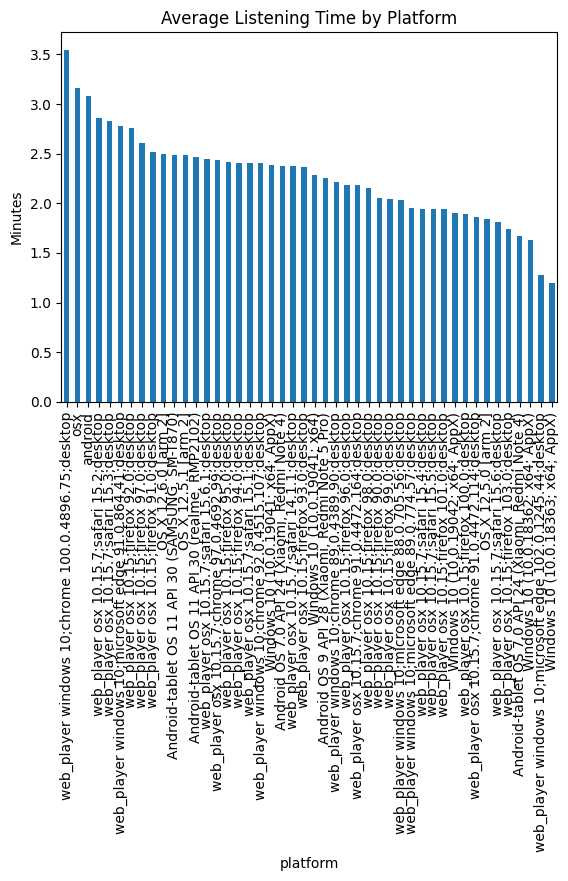

In [12]:
#PLATFORM LISTENING TIME
platform_minutes = (
    events_df
    .groupby('platform')['minutes_played']
    .mean()
    .sort_values(ascending=False)
)

platform_minutes.plot(kind='bar')

plt.title("Average Listening Time by Platform")

plt.ylabel("Minutes")

plt.show()

CONTENT ANALYSIS

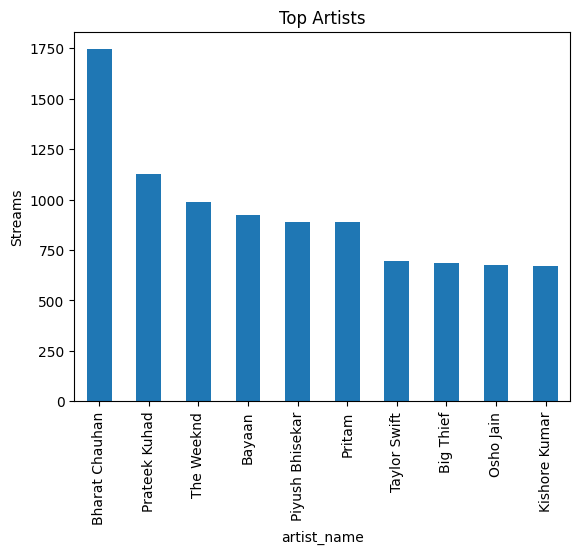

In [14]:
#TOP ARTIST
top_artists = (
    events_df['artist_name']
    .value_counts()
    .head(10)
)

top_artists.plot(kind='bar')

plt.title("Top Artists")

plt.ylabel("Streams")

plt.show()


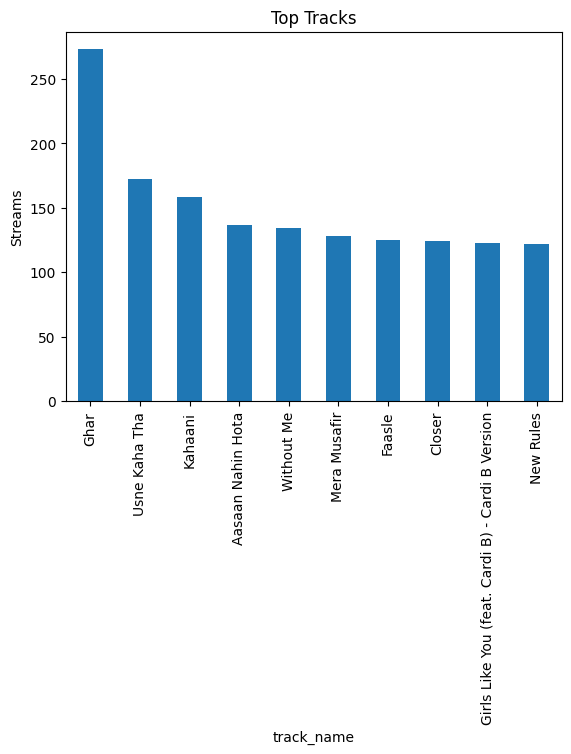

In [15]:
#TOP TRACKS
top_tracks = (
    events_df['track_name']
    .value_counts()
    .head(10)
)

top_tracks.plot(kind='bar')

plt.title("Top Tracks")

plt.ylabel("Streams")

plt.show()

BEHAVIOURAL ANALYTICS

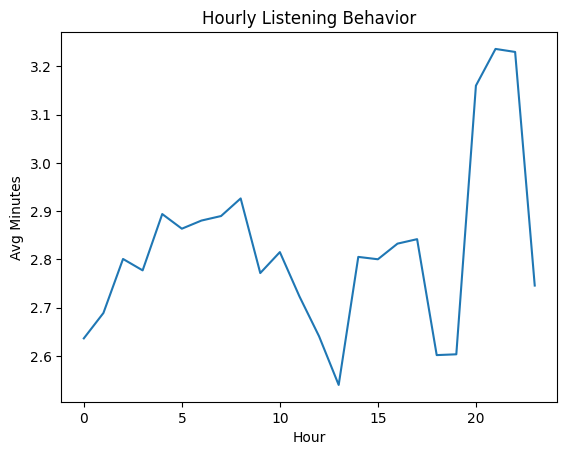

In [16]:
#HOURLY LISTENING Pattern
hourly_behavior = (
    events_df
    .groupby('hour')['minutes_played']
    .mean()
)

hourly_behavior.plot()

plt.title("Hourly Listening Behavior")

plt.xlabel("Hour")

plt.ylabel("Avg Minutes")

plt.show()

In [17]:
#WEEKENDS VS WEEKDAYS
events_df.groupby(
    'is_weekend'
)['minutes_played'].mean()

is_weekend
False    2.795407
True     2.750019
Name: minutes_played, dtype: float64

In [19]:
#NIGHT LISTENING
events_df.groupby(
    'night_listener'
)['minutes_played'].mean()

night_listener
0    2.775239
1    2.802793
Name: minutes_played, dtype: float64

FUTURE ADOPTION ANALYTICS

In [20]:
#SHUFFLE ADOPTION
events_df['shuffle'].value_counts(normalize=True)

shuffle
False    0.722398
True     0.277602
Name: proportion, dtype: float64

In [21]:
#SHUFFLE VS ENGAGEMENT
events_df.groupby(
    'shuffle'
)['minutes_played'].mean()

shuffle
False    2.772284
True     2.810471
Name: minutes_played, dtype: float64

FUNNEL ANALYTICS

In [22]:
#SIMULATED FUNNEL
funnel = pd.DataFrame({
    'stage': [
        'Play Song',
        'High Engagement',
        'Shuffle Usage',
        'Long Session'
    ],
    'users': [
        len(events_df),
        len(events_df[
            events_df['engagement_level']
            == 'high_engagement'
        ]),
        len(events_df[
            events_df['shuffle'] == True
        ]),
        len(events_df[
            events_df['minutes_played'] > 10
        ])
    ]
})

funnel

,stage,users
0,Play Song,54171
1,High Engagement,28243
2,Shuffle Usage,15038
3,Long Session,75


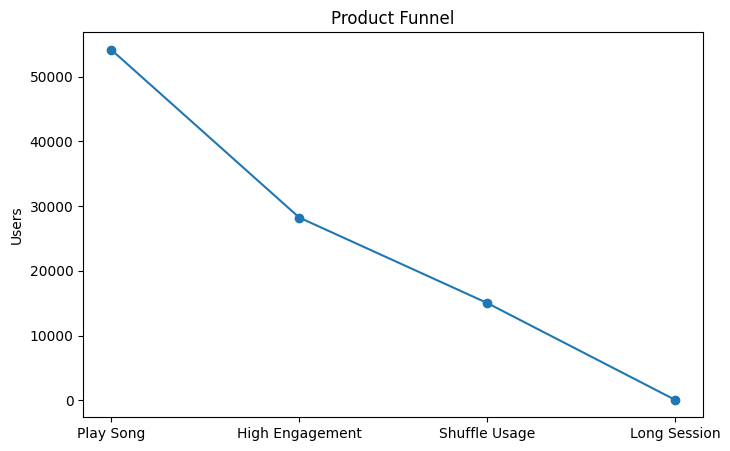

In [23]:
#FUNNEL VISUALIZATION
plt.figure(figsize=(8,5))

plt.plot(
    funnel['stage'],
    funnel['users'],
    marker='o'
)

plt.title("Product Funnel")

plt.ylabel("Users")

plt.show()

In [24]:
#kpi tables export
dau.to_csv(
    "../kpi_tables/dau.csv",
    index=False
)

wau.to_csv(
    "../kpi_tables/wau.csv",
    index=False
)

mau.to_csv(
    "../kpi_tables/mau.csv",
    index=False
)

funnel.to_csv(
    "../kpi_tables/funnel.csv",
    index=False
)